# NAS Results Analysis
Run while training is in progress or after completion.
Reads metrics.json files + evaluates the best saved model.

  9 candidates | generations: [np.int64(0)]
 gen  idx  params  fp32_iou  fp16_iou  fitness
   0    0   79891  0.420114  0.441353 0.641353
   0    1  391244  0.505551  0.488307 0.688307
   0    2  579150  0.394006  0.444452 0.644452
   0    3  410934  0.377081  0.373709 0.573709
   0    4  205925  0.501814  0.561872 0.761872
   0    5    6475  0.264403  0.290638 0.490638
   0    6    5389  0.301734  0.234910 0.434910
   0    7   20845  0.474355  0.475811 0.675811
   0    8  253680  0.405727  0.472026 0.672026

  fp16_iou  mean=0.4203  max=0.5619  min=0.2349
  Best: gen=0 idx=4 params=205,925 fp32=0.5018  fp16=0.5619

--- Model file check ---
  fp32_model: models_traced/generation_0/model_4/model_fp32.pt  exists=True
  fp16_model: models_traced/generation_0/model_4/model_fp16aware.pt  exists=True
  pkl: models_traced/src/population_0.pkl  exists=True
  pkl has 45 individuals
  individual 4 layers: [{'layer_type': 'ConvAct', 'out_channels_coefficient': 4, 'kernel_size': '5', 'stride': '1'

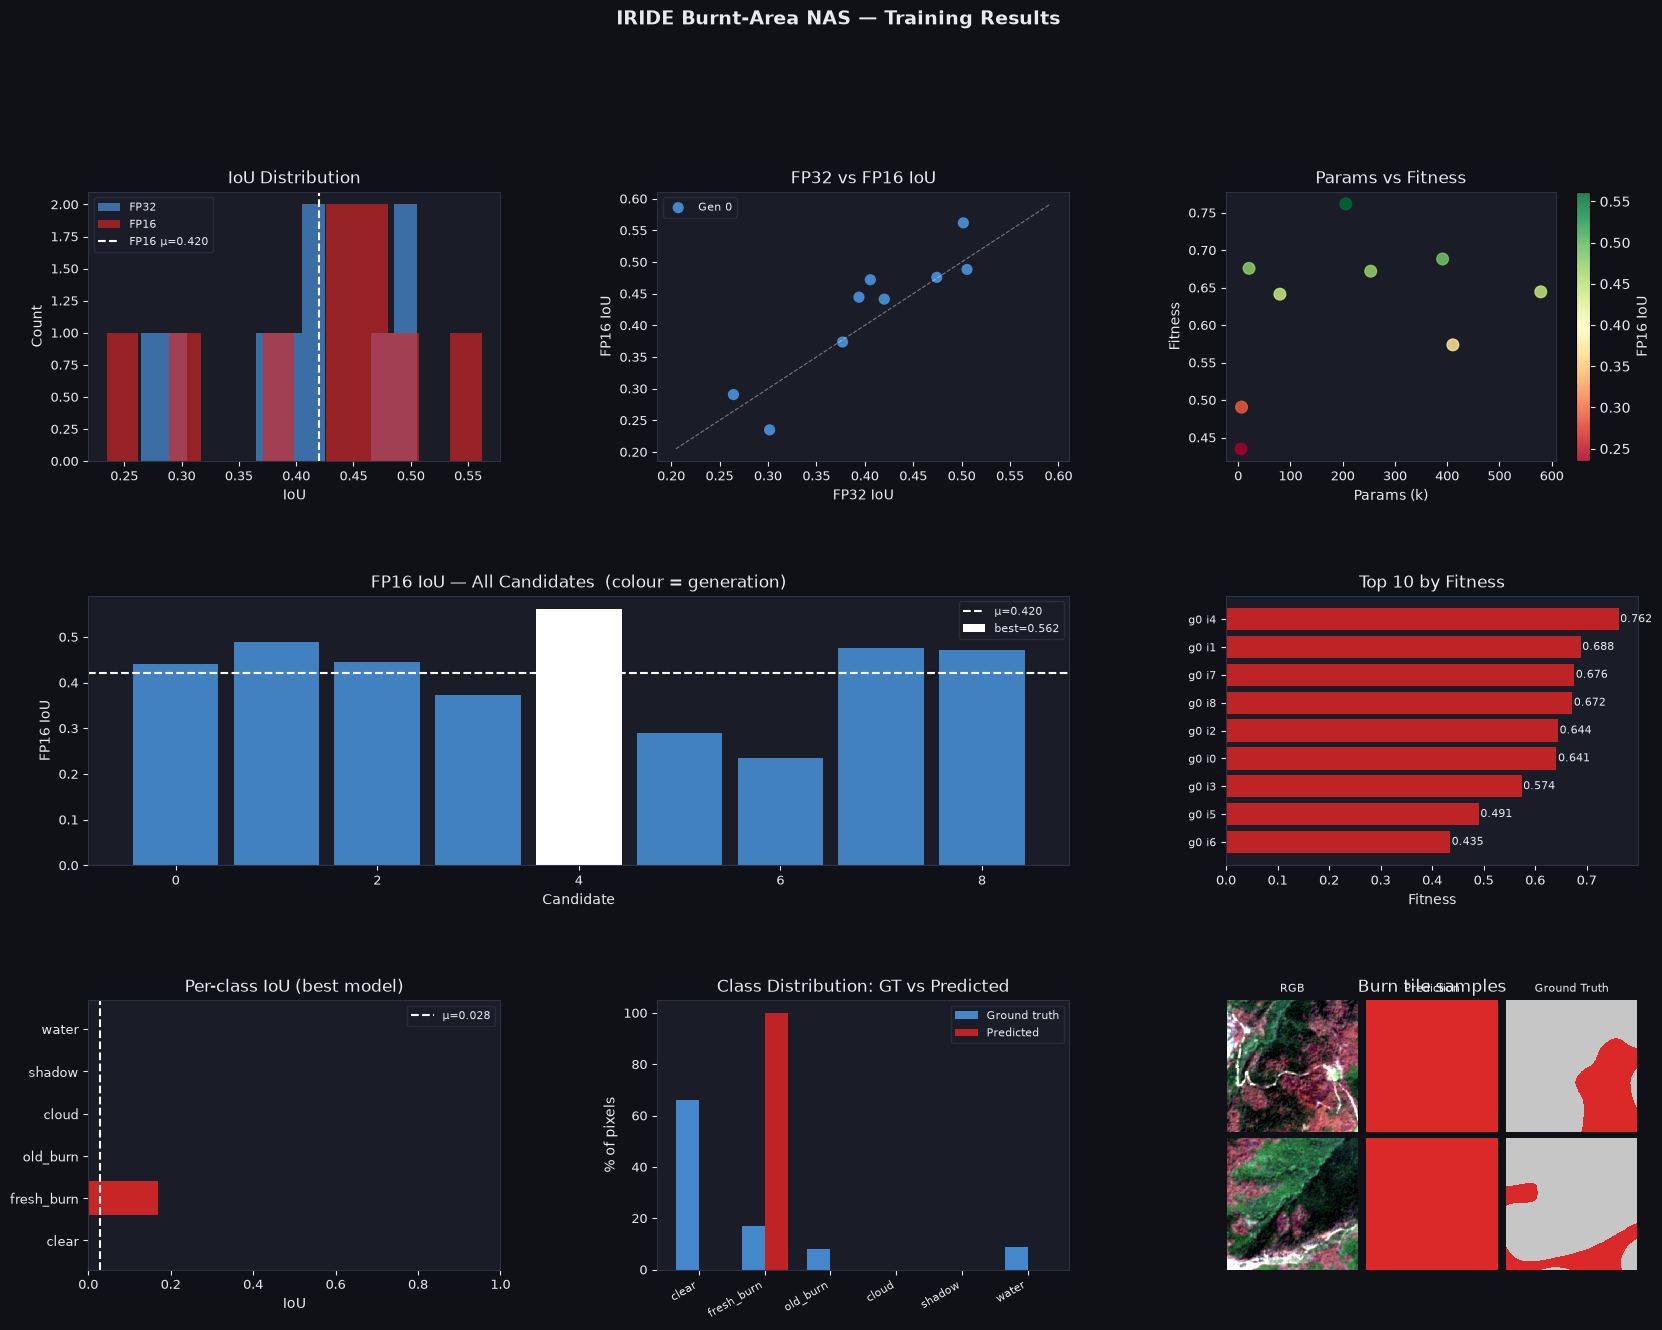


Saved → models_traced/nas_results.png


In [1]:
import os, sys, glob, json, pickle, warnings, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
warnings.filterwarnings("ignore")

os.chdir(os.path.expanduser("~/projects/iride_onboard-burnscar-mapper"))
sys.path.insert(0, "training"); sys.path.insert(0, "."); sys.path.insert(0, "pyqnas/src")

from dataset import TileDataset

SAVE_DIR    = "models_traced"
CLASS_NAMES = ["clear","fresh_burn","old_burn","cloud","shadow","water"]
BURN_COLORS = ["#c8c8c8","#dc2626","#8b4513","#e0e0e0","#3d3d59","#1e5ab9"]
DARK, LIGHT, ACC = "#0f1117", "#e8eaf0", "#dc2626"
GEN_PAL = ["#4c9be8","#e8834c","#4ce88a","#e8dc4c"]

rows = []
for p in sorted(glob.glob(f"{SAVE_DIR}/generation_*/model_*/metrics.json")):
    try:
        m = json.load(open(p)); m["path"] = p; rows.append(m)
    except Exception:
        pass

assert rows, "No metrics.json found — re-run once a candidate completes."

df   = pd.DataFrame(rows).sort_values(["gen","idx"]).reset_index(drop=True)
best = df.sort_values("fp16_iou", ascending=False).iloc[0]

print(f"{'='*60}")
print(f"  {len(df)} candidates | generations: {sorted(df['gen'].unique())}")
print(f"{'='*60}")
print(df[["gen","idx","params","fp32_iou","fp16_iou","fitness"]].to_string(index=False))
print(f"\n  fp16_iou  mean={df['fp16_iou'].mean():.4f}  "
      f"max={df['fp16_iou'].max():.4f}  min={df['fp16_iou'].min():.4f}")
print(f"  Best: gen={best['gen']} idx={best['idx']} params={best['params']:,} "
      f"fp32={best['fp32_iou']:.4f}  fp16={best['fp16_iou']:.4f}")

print(f"\n--- Model file check ---")
for col in ["fp32_model","fp16_model"]:
    p = best.get(col,"")
    print(f"  {col}: {p}  exists={os.path.exists(str(p))}")

pkl_path = f"{SAVE_DIR}/src/population_0.pkl"
print(f"  pkl: {pkl_path}  exists={os.path.exists(pkl_path)}")
if os.path.exists(pkl_path):
    pop_list = pickle.load(open(pkl_path,"rb"))
    print(f"  pkl has {len(pop_list)} individuals")
    idx_num = int(best["idx"])
    if idx_num < len(pop_list):
        print(f"  individual {idx_num} layers: {pop_list[idx_num].parsed_layers}")
    else:
        print(f"  !! idx={idx_num} out of range (pkl has {len(pop_list)})")

def sax(ax):
    ax.set_facecolor("#1a1d27")
    for sp in ax.spines.values(): sp.set_color("#2d3142")
    ax.tick_params(colors=LIGHT, labelsize=9)
    ax.xaxis.label.set_color(LIGHT); ax.yaxis.label.set_color(LIGHT)
    ax.title.set_color(LIGHT)
    return ax

fig = plt.figure(figsize=(20,14)); fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

ax = sax(fig.add_subplot(gs[0,0]))
ax.hist(df["fp32_iou"], bins=12, color="#4c9be8", alpha=0.65, label="FP32")
ax.hist(df["fp16_iou"], bins=12, color=ACC, alpha=0.65, label="FP16")
ax.axvline(df["fp16_iou"].mean(), color="white", lw=1.5, ls="--",
           label=f"FP16 μ={df['fp16_iou'].mean():.3f}")
ax.set_title("IoU Distribution"); ax.set_xlabel("IoU"); ax.set_ylabel("Count")
ax.legend(fontsize=8, labelcolor=LIGHT, facecolor="#1a1d27", edgecolor="#2d3142")

ax = sax(fig.add_subplot(gs[0,1]))
for g in sorted(df["gen"].unique()):
    s = df[df["gen"]==g]
    ax.scatter(s["fp32_iou"], s["fp16_iou"], c=GEN_PAL[g%4],
               label=f"Gen {g}", alpha=0.85, s=65, edgecolors="none")
lims = [df[["fp32_iou","fp16_iou"]].min().min()-.03,
        df[["fp32_iou","fp16_iou"]].max().max()+.03]
ax.plot(lims, lims, "w--", lw=0.8, alpha=0.4)
ax.set_title("FP32 vs FP16 IoU"); ax.set_xlabel("FP32 IoU"); ax.set_ylabel("FP16 IoU")
ax.legend(fontsize=8, labelcolor=LIGHT, facecolor="#1a1d27", edgecolor="#2d3142")

ax = sax(fig.add_subplot(gs[0,2]))
sc = ax.scatter(df["params"]/1e3, df["fitness"], c=df["fp16_iou"],
                cmap="RdYlGn", alpha=0.85, s=70,
                vmin=df["fp16_iou"].min(), vmax=df["fp16_iou"].max())
cb = plt.colorbar(sc, ax=ax); cb.set_label("FP16 IoU", color=LIGHT)
cb.ax.yaxis.label.set_color(LIGHT); cb.ax.tick_params(colors=LIGHT)
ax.set_title("Params vs Fitness"); ax.set_xlabel("Params (k)"); ax.set_ylabel("Fitness")

ax = sax(fig.add_subplot(gs[1,0:2]))
x = np.arange(len(df))
ax.bar(x, df["fp16_iou"], color=[GEN_PAL[g%4] for g in df["gen"]], alpha=0.8, width=0.85)
ax.axhline(df["fp16_iou"].mean(), color="white", lw=1.5, ls="--",
           label=f"μ={df['fp16_iou'].mean():.3f}")
bx = df["fp16_iou"].idxmax()
ax.bar(bx, df["fp16_iou"].iloc[bx], color="white", alpha=1., width=0.85,
       label=f"best={df['fp16_iou'].max():.3f}")
ax.set_title("FP16 IoU — All Candidates  (colour = generation)")
ax.set_xlabel("Candidate"); ax.set_ylabel("FP16 IoU")
ax.legend(fontsize=8, labelcolor=LIGHT, facecolor="#1a1d27", edgecolor="#2d3142")
for g0 in df.groupby("gen").apply(lambda r: r.index[0]).values[1:]:
    ax.axvline(g0-.5, color="#2d3142", lw=1.5)

ax = sax(fig.add_subplot(gs[1,2]))
t10  = df.sort_values("fitness", ascending=False).head(10)
bars = ax.barh(range(len(t10)), t10["fitness"], color=ACC, alpha=0.85)
ax.set_yticks(range(len(t10)))
ax.set_yticklabels([f"g{r.gen} i{r.idx}" for _,r in t10.iterrows()], fontsize=8)
ax.set_title("Top 10 by Fitness"); ax.set_xlabel("Fitness"); ax.invert_yaxis()
for bar, val in zip(bars, t10["fitness"]):
    ax.text(bar.get_width()+.003, bar.get_y()+bar.get_height()/2,
            f"{val:.3f}", va="center", color=LIGHT, fontsize=8)

per_class_iou = np.zeros(6)
gt_frac = np.zeros(6); pred_frac = np.zeros(6)
model_loaded  = False

try:
    from pynas.core.population import Population
    from pynas.core.config import load_default_config

    gen_n   = int(best["gen"])
    idx_num = int(best["idx"])
    pkl = f"{SAVE_DIR}/src/population_{gen_n}.pkl"
    if not os.path.exists(pkl):
        pkl = f"{SAVE_DIR}/src/population_0.pkl"
    print(f"\n  Using pkl: {pkl}")

    config = load_default_config()
    class _DM:
        input_shape = (7, 256, 256); num_classes = 6

    pop = Population(n_individuals=50, max_layers=7, dm=_DM(),
                     max_parameters=3_000_000, save_directory=SAVE_DIR)
    pop_list = pickle.load(open(pkl, "rb"))
    pop.population = pop_list
    pop.cfg = config

    if idx_num >= len(pop_list):
        print(f"  !! idx={idx_num} out of range — using 0")
        idx_num = 0

    model, _ = pop.build_model(pop_list[idx_num].parsed_layers, task="segmentation")
    lp = str(best.get("fp16_model",""))
    if not os.path.exists(lp):
        lp = str(best.get("fp32_model",""))
    assert os.path.exists(lp), f"No model file: {lp}"
    print(f"  Loading: {lp}")

    state = torch.load(lp, map_location="cuda")
    if any(k.startswith("module.") for k in state):
        state = {k.replace("module.","",1): v for k,v in state.items()}
    model.load_state_dict(state, strict=False)
    model = model.cuda().eval()
    print(f"  Ready — {sum(p.numel() for p in model.parameters()):,} params")

    tiles  = pd.read_csv("processed/dataset_v1/tiles_index.csv")
    val_df = tiles[(tiles.split=="val") & (tiles.gsd=="native")].reset_index(drop=True)
    ds     = TileDataset("processed/dataset_v1", val_df, is_train=False)
    n_eval = min(400, len(ds))
    inters = np.zeros(6); unions = np.zeros(6)
    pc = np.zeros(6);     gc = np.zeros(6)

    with torch.no_grad():
        for i in range(n_eval):
            img, mask = ds[i]
            pred = model(img.unsqueeze(0).cuda()).argmax(1).squeeze().cpu().numpy()
            gt = mask.numpy(); valid = gt != -1
            for c in range(6):
                p = (pred==c)&valid; g = (gt==c)&valid
                inters[c] += (p&g).sum(); unions[c] += (p|g).sum()
                pc[c] += p.sum();         gc[c] += g.sum()

    per_class_iou = inters / np.maximum(unions, 1)
    total = max(gc.sum(), 1)
    gt_frac = gc/total; pred_frac = pc/total
    model_loaded = True

    print(f"\n  Per-class IoU ({n_eval} val tiles):")
    print(f"  {'Class':<14} {'GT%':>6} {'Pred%':>6} {'IoU':>8}")
    print(f"  {'-'*40}")
    for i, name in enumerate(CLASS_NAMES):
        flag = " ◄" if "burn" in name else ""
        print(f"  {name:<14} {gt_frac[i]*100:>5.1f}% {pred_frac[i]*100:>5.1f}%"
              f" {per_class_iou[i]:>8.4f}{flag}")
    print(f"  {'-'*40}")
    print(f"  {'mean IoU':<21} {per_class_iou.mean():>8.4f}")
    print(f"  {'burn avg':<21} {per_class_iou[1:3].mean():>8.4f}")

except Exception:
    traceback.print_exc()
    print("\n  !! Model eval failed — see traceback above")

ax6 = sax(fig.add_subplot(gs[2,0]))
if model_loaded:
    ax6.barh(CLASS_NAMES, per_class_iou, color=BURN_COLORS, alpha=0.9)
    ax6.axvline(per_class_iou.mean(), color="white", lw=1.5, ls="--",
                label=f"μ={per_class_iou.mean():.3f}")
    ax6.set_xlim(0, 1)
    ax6.legend(fontsize=8, labelcolor=LIGHT, facecolor="#1a1d27", edgecolor="#2d3142")
else:
    ax6.text(0.5, 0.5, "Not available\n(see traceback)", ha="center", va="center",
             color=LIGHT, transform=ax6.transAxes)
ax6.set_title("Per-class IoU (best model)"); ax6.set_xlabel("IoU")

ax7 = sax(fig.add_subplot(gs[2,1]))
if model_loaded:
    x7 = np.arange(6); w = 0.35
    ax7.bar(x7-w/2, gt_frac*100, width=w, label="Ground truth", color="#4c9be8", alpha=0.85)
    ax7.bar(x7+w/2, pred_frac*100, width=w, label="Predicted", color=ACC, alpha=0.85)
    ax7.set_xticks(x7)
    ax7.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=8)
    ax7.set_ylabel("% of pixels")
    ax7.legend(fontsize=8, labelcolor=LIGHT, facecolor="#1a1d27", edgecolor="#2d3142")
else:
    ax7.axis("off")
ax7.set_title("Class Distribution: GT vs Predicted")

ax8 = sax(fig.add_subplot(gs[2,2]))
ax8.axis("off"); ax8.set_title("Burn tile samples", color=LIGHT)

if model_loaded:
    try:
        tiles2  = pd.read_csv("processed/dataset_v1/tiles_index.csv")
        burn_df = tiles2[(tiles2.split=="val") & (tiles2.gsd=="native") &
                         (tiles2["frac_2"]>0.1)].head(2).reset_index(drop=True)

        def mask_rgb(m):
            cmap = {0:(.78,.78,.78),1:(.86,.16,.16),2:(.55,.31,.16),
                    3:(.95,.95,.95),4:(.24,.24,.35),5:(.12,.35,.78),-1:(0,0,0)}
            out = np.ones((*m.shape,3))
            for v,c in cmap.items(): out[m==v] = c
            return out

        if len(burn_df):
            inner = gridspec.GridSpecFromSubplotSpec(
                len(burn_df), 3, subplot_spec=gs[2,2], hspace=0.05, wspace=0.05)
            for ri in range(len(burn_df)):
                ds_b = TileDataset("processed/dataset_v1",
                                   burn_df.iloc[[ri]].reset_index(drop=True), is_train=False)
                img_t, mask_t = ds_b[0]
                with torch.no_grad():
                    pred_t = model(img_t.unsqueeze(0).cuda()).argmax(1).squeeze().cpu().numpy()
                rgb = img_t.numpy()[[2,1,0]].transpose(1,2,0)
                lo, hi = (np.percentile(rgb[rgb>0],[2,98]) if (rgb>0).any() else (0,1))
                rgb = np.clip((rgb-lo)/(hi-lo+1e-6),0,1)
                for ci,(data,title) in enumerate([
                    (rgb,"RGB"),(mask_rgb(pred_t),"Prediction"),(mask_rgb(mask_t.numpy()),"Ground Truth")
                ]):
                    a = fig.add_subplot(inner[ri,ci])
                    a.set_facecolor("#1a1d27"); a.imshow(data,interpolation="nearest")
                    if ri==0: a.set_title(title,color=LIGHT,fontsize=8)
                    a.axis("off")
    except Exception:
        traceback.print_exc()

fig.suptitle("IRIDE Burnt-Area NAS — Training Results",
             color=LIGHT, fontsize=14, fontweight="bold", y=1.01)
out = f"{SAVE_DIR}/nas_results.png"
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()
print(f"\nSaved → {out}")

In [2]:
import numpy as np, torch

CLASS_PIXEL_FREQS = np.array([0.661, 0.154, 0.065, 0.004, 0.001, 0.110])
CLASS_WEIGHTS = torch.from_numpy(
    (1.0 / np.maximum(CLASS_PIXEL_FREQS, 1e-4)) /
    (1.0 / np.maximum(CLASS_PIXEL_FREQS, 1e-4)).sum()
).float()

print("Class weights:")
for name, w in zip(["clear","fresh_burn","old_burn","cloud","shadow","water"], CLASS_WEIGHTS):
    print(f"  {name:<14}: {w:.4f}")
print(f"  sum: {CLASS_WEIGHTS.sum():.4f}")

Class weights:
  clear         : 0.0012
  fresh_burn    : 0.0051
  old_burn      : 0.0120
  cloud         : 0.1949
  shadow        : 0.7797
  water         : 0.0071
  sum: 1.0000
